**MAESTRÍA EN INTELIGENCIA ARTIFICIAL APLICADA**

**Curso: TC5053 - Ciencia y analítica de datos**

Tecnológico de Monterrey

Prof Grettel Barceló Alonso

**Semana 4**
Exploración de datos

---

*   NOMBRE: Fernando Gomez Moreno
*   MATRÍCULA: A00354097

En esta actividad trabajarás con el archivo `personal_loan.csv`, basado en un conjunto de datos sobre clientes bancarios y su comportamiento financiero disponible en Kaggle.

Los datos fueron recopilados para analizar la posibilidad de que los clientes acepten un préstamo personal y contienen información demográfica, financiera y de productos bancarios asociados. Los indicadores incluidos son:

* `ID`: Identificador único del cliente
* `Age`: Edad del cliente (años completos)
* `Experience`: Experiencia laboral en años
* `Income`: Ingreso anual del cliente (en miles de dólares. Por ejemplo, 60 = 60,000 USD/año)
* `ZIP Code`: Código postal del cliente
* `Family`: Número de miembros de la familia
* `CCAvg`: Promedio de gastos mensuales con tarjeta de crédito (en miles de dólares)
* `Education`: Nivel educativo (1 = graduado, 2 = universitario, 3 = posgrado)
* `Mortgage`: Monto de hipoteca que posee el cliente (en miles de dólares)
* `Securities Account`: Indicador de si tiene cuenta de valores (1 = sí, 0 = no)
* `CD Account`: Indicador de si tiene cuenta de certificado de depósito (1 = sí, 0 = no)
* `Online`: Indicador de si usa los servicios bancarios en línea (1 = sí, 0 = no)
* `CreditCard`: Indicador de si es titular de tarjeta de crédito (1 = sí, 0 = no)
* `Personal Loan`: Si el cliente aceptó (1) o no (0) un préstamo personal. Es la variable de salida o *target*, es decir, la que se pretende predecir más adelante al construir el modelo

**NOTA IMPORTANTE:** Asegúrate de responder *explícitamente* todos los cuestionamientos.

In [82]:
# Importar las bibliotecas necesarias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import norm

1. Descarga el archivo: `personal_loan.csv` y guarda, en un dataframe (`loan_df`), todos sus registros.
* Haz que la columna `ID` sea el índice del dataframe.
* Utiliza el método `info()` del dataframe, para obtener el resumen de los tipos de datos. ¿Cuántas columnas son numéricas y cuántas de texto?

In [83]:
loan_df = pd.read_csv("personal_loan.csv")
loan_df.set_index('ID', inplace=True)
loan_df.info()

#Cuántas columnas son numéricas? 8 columnas son numéricas.
#Cuántas columnas son text? 5 columnas son de object que pueden ser texto.

# Para mi referencia existen 5037 registros en el dataframe.

<class 'pandas.core.frame.DataFrame'>
Index: 5037 entries, 0 to 5036
Data columns (total 13 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Age                 5037 non-null   int64  
 1   Experience          5037 non-null   int64  
 2   Income              5037 non-null   int64  
 3   ZIP Code            5037 non-null   int64  
 4   Family              5037 non-null   int64  
 5   CCAvg               5037 non-null   float64
 6   Education           5037 non-null   float64
 7   Mortgage            5037 non-null   int64  
 8   Personal Loan       5037 non-null   object 
 9   Securities Account  5037 non-null   object 
 10  CD Account          5037 non-null   object 
 11  Online              5037 non-null   object 
 12  CreditCard          5037 non-null   object 
dtypes: float64(2), int64(6), object(5)
memory usage: 550.9+ KB


# Limpieza

2. Obtén las estadísticas descriptivas de las variables numéricas y examina cuidadosamente los valores obtenidos de cada columna.
* Filtra el dataframe para visualizar los registros en que la edad supera los 100 años y elimínalos si no son pausibles.
* Analiza el resto de las variables y elimina aquellos registros que contengan valores inválidos o inconsistentes. Para cada acción que realices, justifica la decisión, explicando por qué consideras que el valor es incorrecto.
* ¿Cuántos registros se eliminaron (considerando todas las acciones de este ejercicio) y qué porcentaje representa respecto al total del dataframe inicial?

In [84]:
registros_edad_mas_de_100 = loan_df[loan_df['Age'] > 100]
# Son 3 registros donde la edad son mayor a 100, esos son los IDs: 10, 250 y 4800
loan_df = loan_df[loan_df['Age'] <= 100]
# Aqui elimino los 3 ùnicos registros donde las edades son mayores a 100 porque son edades que tienen valores atipicos.
# Ahora el total de registros es 5034 después de la limpieza.

# Checar si hay valores nulos.
# print(loan_df.isnull().sum())
# No hay valores nulos

# Hay que poner los valores de 0 y 1 a No y Yes respectivamente ya que son tipo object hay que tratarlas como string
columnas_convertir_a_boolean = ['Personal Loan','Securities Account','CD Account','Online','CreditCard']
loan_df.loc[:, columnas_convertir_a_boolean] = loan_df.loc[:, columnas_convertir_a_boolean].replace({'0': 'No', '1': 'Yes'})

# Eliminar el zip code con 4 digitos ya que los zip codes del dataframe son zip codes de Estados Unidos y no hay de 4 o menos digitos.
loan_df['ZIP Code'] = loan_df['ZIP Code'].astype(str).str.strip()
mascara_4_digitos = (loan_df['ZIP Code'].str.len() == 4)
loan_df_limpio = loan_df[~mascara_4_digitos].copy()
registros_eliminados = len(loan_df) - len(loan_df_limpio)
loan_df = loan_df_limpio
# Dataframe actual tiene 5033 registros

# Limpiar la columna Family, Experience
columnas_a_limpiar = ['Family', 'Experience']
mascara_combinada = True
for columna in columnas_a_limpiar:
    mascara_combinada = mascara_combinada & (loan_df[columna] >= 0)
registros_a_eliminar = len(loan_df) - mascara_combinada.sum()
# Filtrar el dataframe y sobreescribir el original
loan_df = loan_df[mascara_combinada].copy()
# Dataframe tiene ahora 4978 registros

# Se eliminaron los valores menores a 0 para campos como familia y experiencia 
# porque estos campos se deben considerar valores positivos para que den mayor 
# Se eliminaron en total 5037 - 4978 = 59 registros.

# Eliminar valor con punto decimal para Education
mascara_entera = (loan_df['Education'] % 1 == 0)
registros_a_eliminar = len(loan_df) - mascara_entera.sum()
loan_df = loan_df[mascara_entera].copy()
print(f"Se eliminaron {registros_a_eliminar} registros con valores no enteros (decimales) en 'Education'.")
print(f"El DataFrame final 'loan_df' tiene {len(loan_df)} registros.")

valor_inicial = 5037
valor_final = 4977
porcentaje = ((valor_final - valor_inicial) / valor_inicial) * 100
print(f"El percentaje total de registros eliminados con respecto al dataframe inicial es: {porcentaje:.2f}%")



Se eliminaron 1 registros con valores no enteros (decimales) en 'Education'.
El DataFrame final 'loan_df' tiene 4977 registros.
El percentaje total de registros eliminados con respecto al dataframe inicial es: -1.19%


3. Obtén las estadísticas descriptivas de las variables de texto e imprime las frecuencias de sus categorías.
* Algunas columnas almacenan valores binarios utilizando distintos formatos. Unifica estos valores de manera consistente, asegurándote de que coincidan con la descripción de las variables al inicio de esta libreta.

In [85]:
print("--- Estadísticas Descriptivas de Variables de Texto ---")
print(loan_df.describe(include=['object']))

# Anteriormente las columnas que almacenan binarios 0 y 1 para No y Yes, los unifique para que solo sean Yes y No.
# Hay que poner los valores de 0 y 1 a No y Yes respectivamente ya que son tipo object hay que tratarlas como string
columnas_convertir_a_boolean = ['Personal Loan','Securities Account','CD Account','Online','CreditCard']
loan_df.loc[:, columnas_convertir_a_boolean] = loan_df.loc[:, columnas_convertir_a_boolean].replace({'0': 'No', '1': 'Yes'})

--- Estadísticas Descriptivas de Variables de Texto ---
       ZIP Code Personal Loan Securities Account CD Account Online CreditCard
count      4977          4977               4977       4977   4977       4977
unique      467             2                  2          2      2          2
top       94720            No                 No         No    Yes         No
freq        164          4492               4458       4674   2975       3513


4. Verifica si hay registros duplicados y si fuera así, elimínalos del dataframe.
* Asegúrate de reiniciar el índice para mantener una secuencia continua tras todas las eliminaciones de registros que hasta este punto se han realizado.

In [86]:
registros_duplicados = loan_df.duplicated().sum()

print(f"Número de registros duplicados encontrados: {registros_duplicados}")

if registros_duplicados > 0:
    # Aqui eliminamos los registros duplicados.
    # inplace=True modifica el DataFrame loan_df directamente.
    loan_df.drop_duplicates(inplace=True)
    print("Registros duplicados eliminados.")
else:
    print("No se encontraron registros duplicados para eliminar.")

# Verificar el nuevo tamaño del DataFrame
print(f"El DataFrame actual 'loan_df' tiene {len(loan_df)} registros.")
# El DataFrame actual 'loan_df' tiene 4941 registros.

# Reiniciar el índice para mantener una secuencia continua después de borrar duplicados y valores atípicos.
loan_df.reset_index(drop=True, inplace=True)
print(loan_df.head())

Número de registros duplicados encontrados: 36
Registros duplicados eliminados.
El DataFrame actual 'loan_df' tiene 4941 registros.
   Age  Experience  Income ZIP Code  Family  CCAvg  Education  Mortgage  \
0   25           1      49    91108       4    1.6        1.0         0   
1   45          19      34    90089       3    1.5        1.0         0   
2   39          15      11    94720       1    1.0        1.0         0   
3   35           9     100    94112       1    2.7        2.0         0   
4   35           8      45    91330       4    1.0        2.0         0   

  Personal Loan Securities Account CD Account Online CreditCard  
0            No                Yes         No     No         No  
1            No                Yes         No     No         No  
2            No                 No         No     No         No  
3            No                 No         No     No         No  
4            No                 No         No     No        Yes  


5. Aunque hasta ahora se han considerado los tipos de datos inferidos por pandas, antes del EDA es recomendable revisar la naturaleza estadística de cada variable (continua, discreta, categórica, binaria, etc.) para aplicar el análisis adecuado.

* Efectúa las siguientes conversiones:
  - Nominal: ZIP Code - `object`
  - Ordinal: Education - `category` con orden 1, 2, 3
  - Binarias: Personal Loan, Securities Account, CD Account, Online, CreditCard - `category`
* Crea dos listas llamadas `num_cols` y `cat_cols` que contengan los nombres de las variables numéricas (int64, float64) y categóricas (object, category) del dataset, respectivamente.

In [87]:
# Convertir ZIP Code a tipo object que seria String, originalmente estaba como int64 (Nominal)
loan_df['ZIP Code'] = loan_df['ZIP Code'].astype('object')

from pandas.api.types import CategoricalDtype
education_orden = CategoricalDtype(categories=[1, 2, 3], ordered=True)
loan_df['Education'] = loan_df['Education'].astype(education_orden)
print("\nVerificación de la columna 'Education' (Tipo y Orden):")
print(loan_df['Education'].dtype)

columnas_binarias = ['Personal Loan', 'Securities Account', 'CD Account', 'Online', 'CreditCard']

# Convertir las columnas binarias al tipo category
for col in columnas_binarias:
    loan_df[col] = loan_df[col].astype('category')

print("\nVerificación de tipos de datos después de las conversiones binarias:")
print(loan_df[columnas_binarias].dtypes)


Verificación de la columna 'Education' (Tipo y Orden):
category

Verificación de tipos de datos después de las conversiones binarias:
Personal Loan         category
Securities Account    category
CD Account            category
Online                category
CreditCard            category
dtype: object


# Análisis exploratorio de datos (univariado)

6. Para el análisis de las variables numéricas obtén nuevamente las estadísticas descriptivas incluyendo los valores de simetría y curtosis.
* Clasifica las variables `Age`, `Income` y `Mortgage` según los valores observados de asimetría y curtosis.

In [88]:
# Variables numericas
variables_numericas = loan_df.select_dtypes(include=np.number)
# Calcular estadísticas descriptivas estándar
descriptivas = variables_numericas.describe().T
simetria = variables_numericas.skew()
curtosis = variables_numericas.kurt()
statistics_adicionales = pd.DataFrame({
    'Simetria (Skewness)': simetria,
    'Curtosis (Kurtosis)': curtosis
})
estadisticas_finales = descriptivas.join(statistics_adicionales).round(2)

print("Estadísticas Descriptivas de Variables Numéricas (Incluyendo Simetría y Curtosis)")
print(estadisticas_finales)

# Clasifica las variables Age, Income y Mortgage según los valores observados de asimetría y curtosis.

# (Age) skewness es -0.02 es Simetrica, kurtosis es -1.16 es Platicùrtica
# (Income) skewness es 0.84 es ligeramente asimetrica, kurtosis es -0.05 es mesocúrtica
# (Mortage) skewness es 2.10 es Asimétrica, kurtosis es 4.76 es Leptocúrtica

Estadísticas Descriptivas de Variables Numéricas (Incluyendo Simetría y Curtosis)
             count   mean     std   min   25%   50%    75%    max  \
Age         4941.0  45.56   11.32  24.0  36.0  46.0   55.0   67.0   
Experience  4941.0  20.34   11.31   0.0  11.0  20.0   30.0   43.0   
Income      4941.0  73.83   46.11   8.0  39.0  64.0   98.0  224.0   
Family      4941.0   2.39    1.15   1.0   1.0   2.0    3.0    4.0   
CCAvg       4941.0   1.94    1.75   0.0   0.7   1.5    2.6   10.0   
Mortgage    4941.0  56.66  101.88   0.0   0.0   0.0  101.0  635.0   

            Simetria (Skewness)  Curtosis (Kurtosis)  
Age                       -0.02                -1.16  
Experience                -0.02                -1.13  
Income                     0.84                -0.05  
Family                     0.16                -1.40  
CCAvg                      1.59                 2.64  
Mortgage                   2.10                 4.76  


7. Genera un histograma para cada variable numérica, incluyendo la curva KDE y la curva de una distribución normal como referencia.
* Para las variables que clasificaste antes, compara los histogramas generados con los valores numéricos calculados y comenta si la forma de cada distribución coincide con lo esperado.
* Para cada variable, crea un gráfico de boxplot individual que incluya la media.
* Analiza la posición de la media respecto a la mediana. ¿Qué indica esta relación sobre el sesgo (asimetría) de la distribución?

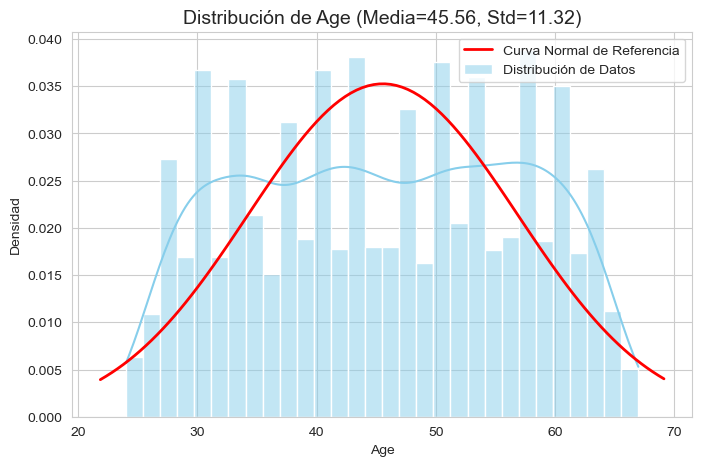

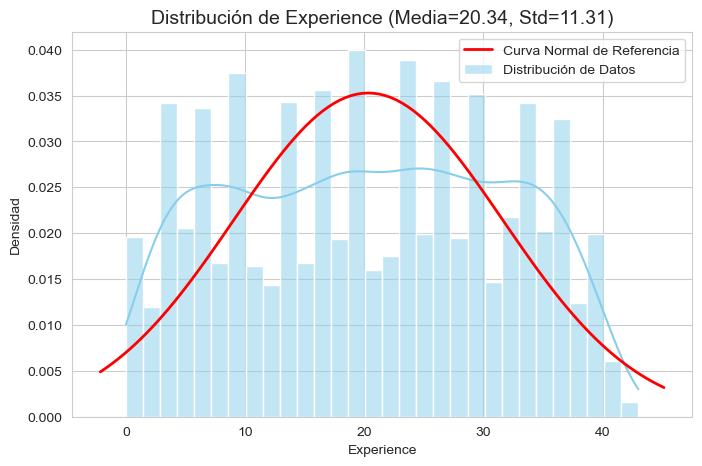

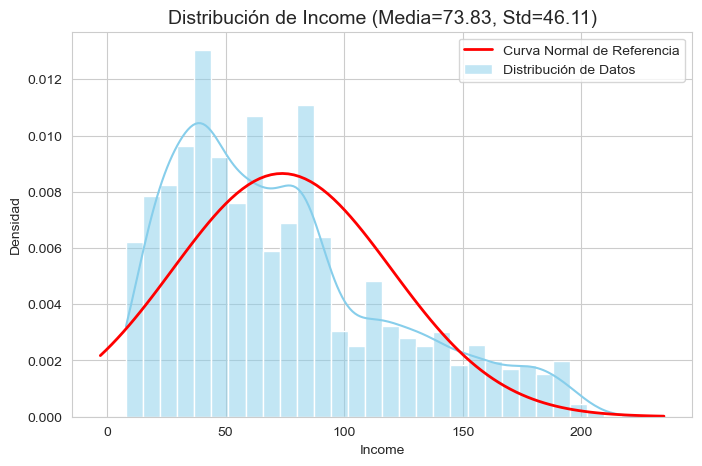

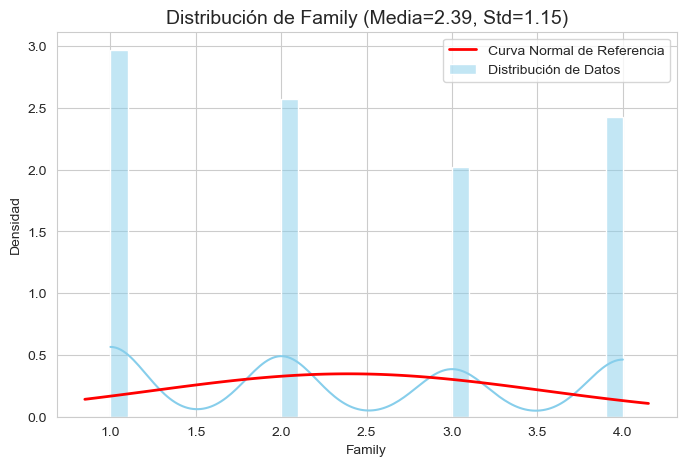

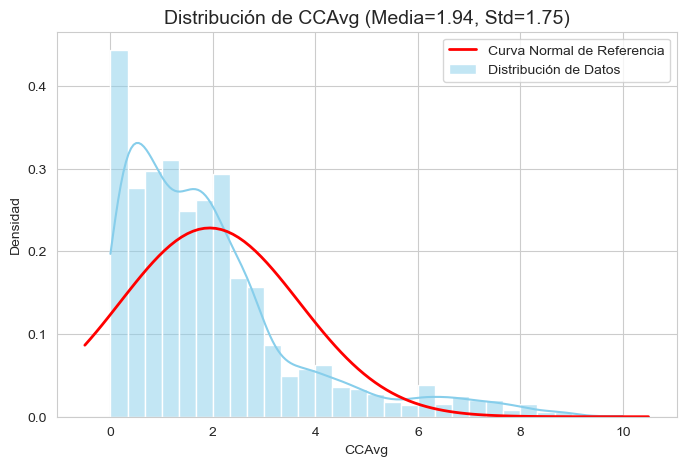

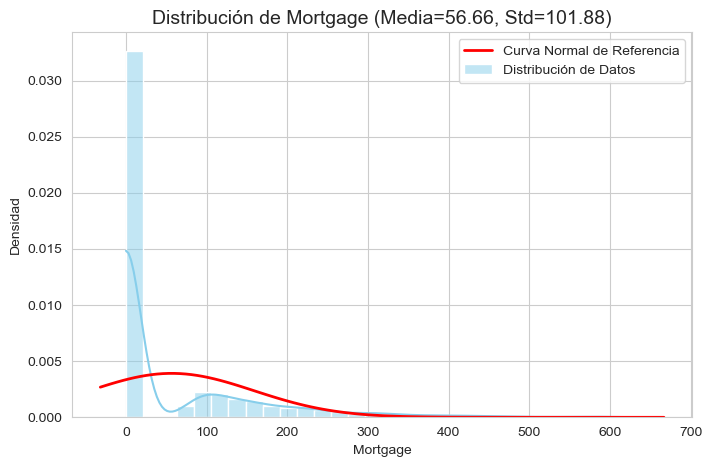

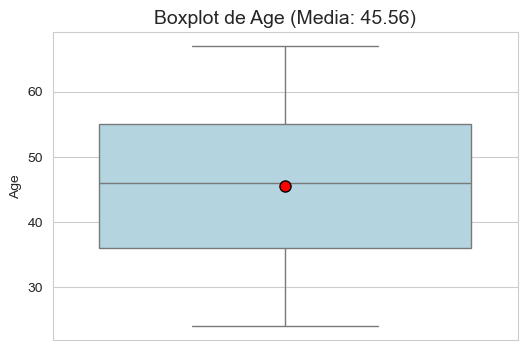

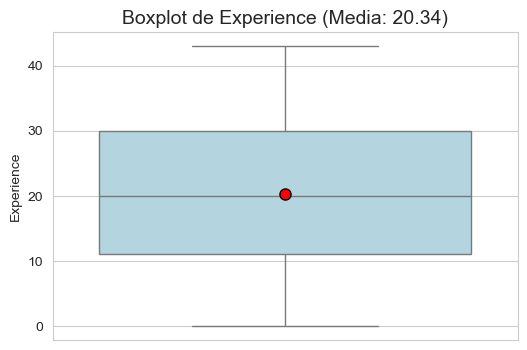

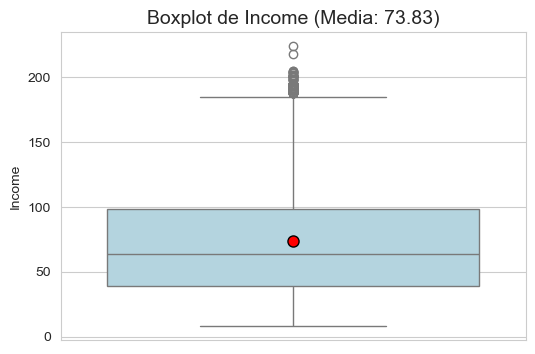

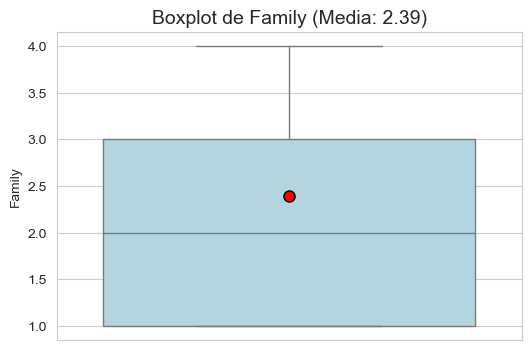

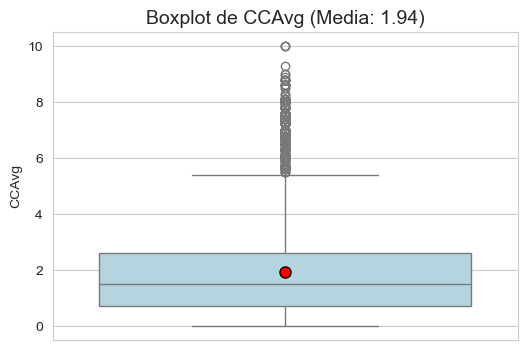

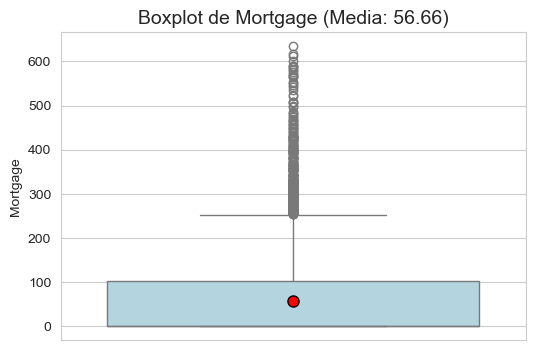

In [89]:
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import norm
import numpy as np
import pandas as pd

variables_numericas = loan_df.select_dtypes(include=np.number).columns

sns.set_style("whitegrid")

for col in variables_numericas:
    plt.figure(figsize=(8, 5))

    # Gráfico principal: Histograma con KDE (stat="density" normaliza el área a 1)
    sns.histplot(loan_df[col], kde=True, stat="density", bins=30, color='skyblue', label='Distribución de Datos')

    # Calcular y dibujar la curva de la Distribución Normal (como referencia)
    mu, sigma = loan_df[col].mean(), loan_df[col].std()
    
    # Definir el rango x para la curva normal
    xmin, xmax = plt.xlim()
    x = np.linspace(xmin, xmax, 100)
    
    # Calcular la función de densidad de probabilidad (PDF) de la Normal
    p = norm.pdf(x, mu, sigma)
    
    # Dibujar la curva Normal
    plt.plot(x, p, 'r', linewidth=2, label='Curva Normal de Referencia')
    
    plt.title(f'Distribución de {col} (Media={mu:.2f}, Std={sigma:.2f})', fontsize=14)
    plt.xlabel(col)
    plt.ylabel('Densidad')
    plt.legend()
    plt.show()

# (Age) skewness es -0.02 es Simetrica, kurtosis es -1.16 es Platicùrtica
# (Income) skewness es 0.84 es ligeramente asimetrica, kurtosis es -0.05 es mesocúrtica
# (Mortage) skewness es 2.10 es Asimétrica, kurtosis es 4.76 es Leptocúrtica

# Para las variables que clasificaste antes, compara los histogramas generados con los valores numéricos calculados 
# y comenta si la forma de cada distribución coincide con lo esperado.

# Para Age la curva es achatada y simetrica, lo cual por los datos obtenidos si coninciden con la gráfica obtenida
# Para Income es positivamente alargada (skew) la gráfica para kurtosis no tienen un pico notoriou y tampoco pico achatada, es eperado para mesocúrtica.
# Para Mortage es Asimétrica la curva no tiene forma con pico y la curva tiende a 0, para kurtosis el valor es muy alto 4.76 es mayor a 0.5 por mucho.


for col in variables_numericas:
    plt.figure(figsize=(6, 4))
    # El parámetro 'showmeans=True' añade un marcador para la media.
    # Definimos el marcador como un círculo rojo ('o') para distinguirlo claramente de la mediana (la línea).
    sns.boxplot(y=loan_df[col], showmeans=True, meanline=False, 
                meanprops={'marker':'o', 'markerfacecolor':'red', 'markeredgecolor':'black', 'markersize':'8'},
                color='lightblue')
    media = loan_df[col].mean()
    plt.title(f'Boxplot de {col} (Media: {media:.2f})', fontsize=14)
    plt.ylabel(col)
    plt.show() 


# Analiza la posición de la media respecto a la mediana. ¿Qué indica esta relación sobre el sesgo (asimetría) de la distribución?
# Para Age la media esta muy cercano a la mediana por lo tanto por eso es simetrica.
# Para Income la media esta en 73.83 la mediana esta alrededor de 69, los outliers estan a la derecha.
# Para Mortage la media esta en 56.66 esta mas cercana al bigote por lo tanto es asimetrica.
    

8. Obtén las estadísticas descriptivas de las variables categóricas.
* Genera un gráfico de barras para cada variable. En las de alta cardinalidad, sólo incluye los 10 valores más relevantes.

       ZIP Code  Education Personal Loan Securities Account CD Account Online  \
count      4941       4941          4941               4941       4941   4941   
unique      467          3             2                  2          2      2   
top       94720          1            No                 No         No    Yes   
freq        163       2079          4462               4426       4640   2951   

       CreditCard  
count        4941  
unique          2  
top            No  
freq         3489  


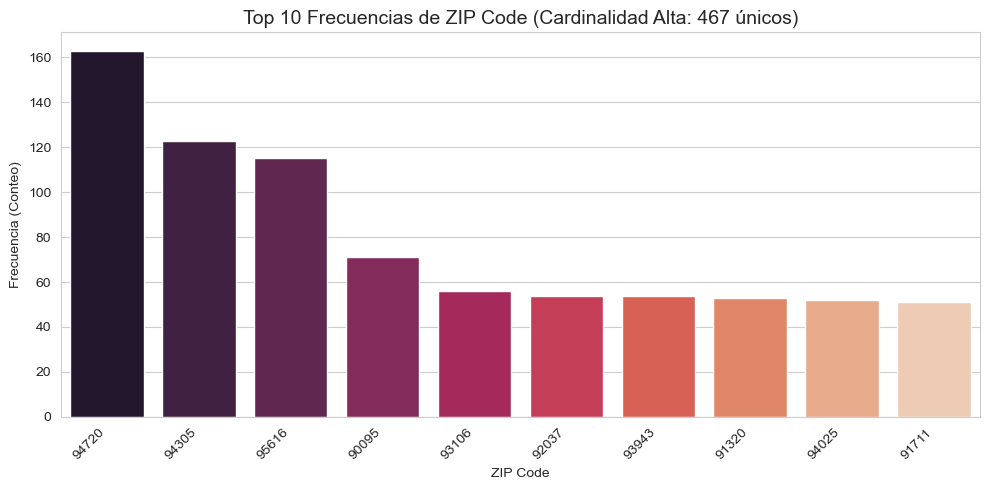

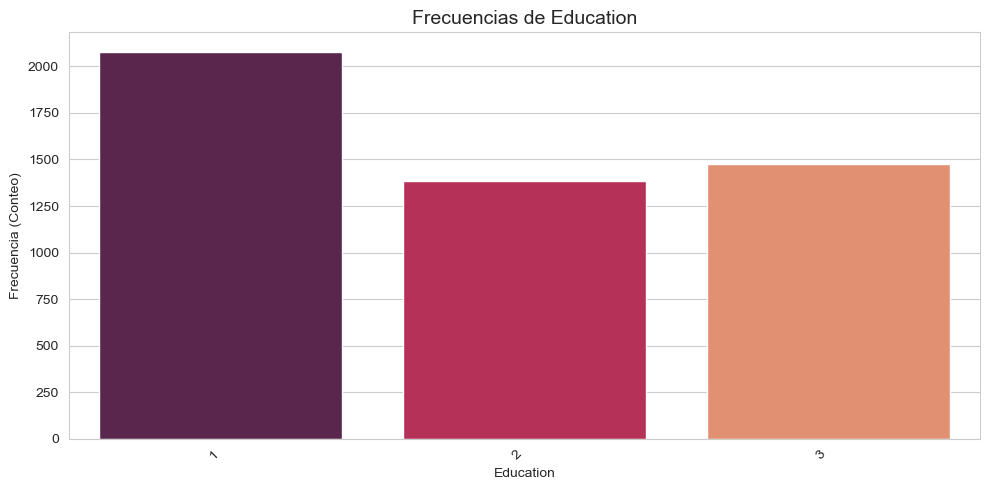

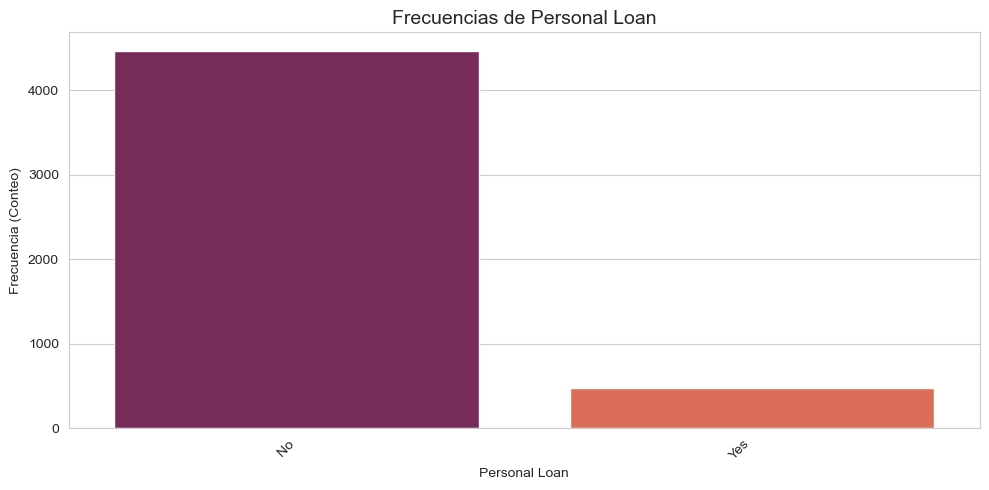

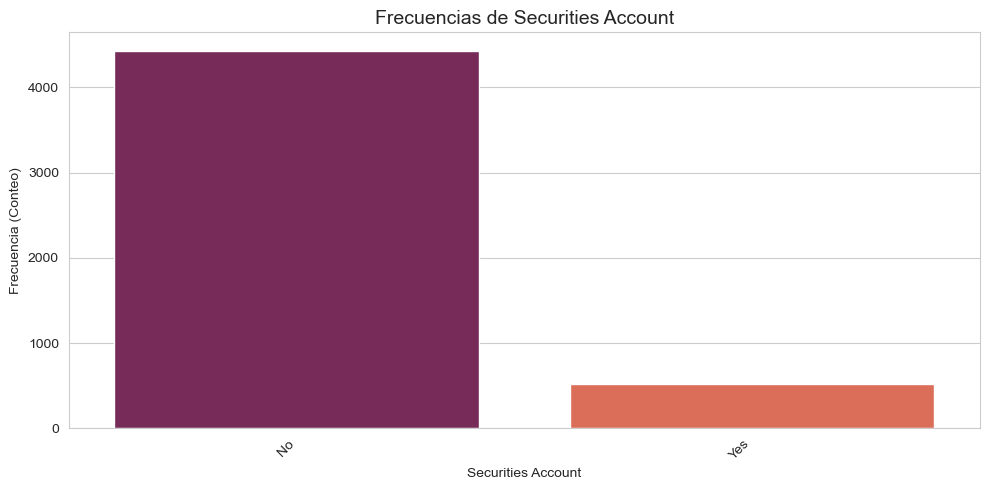

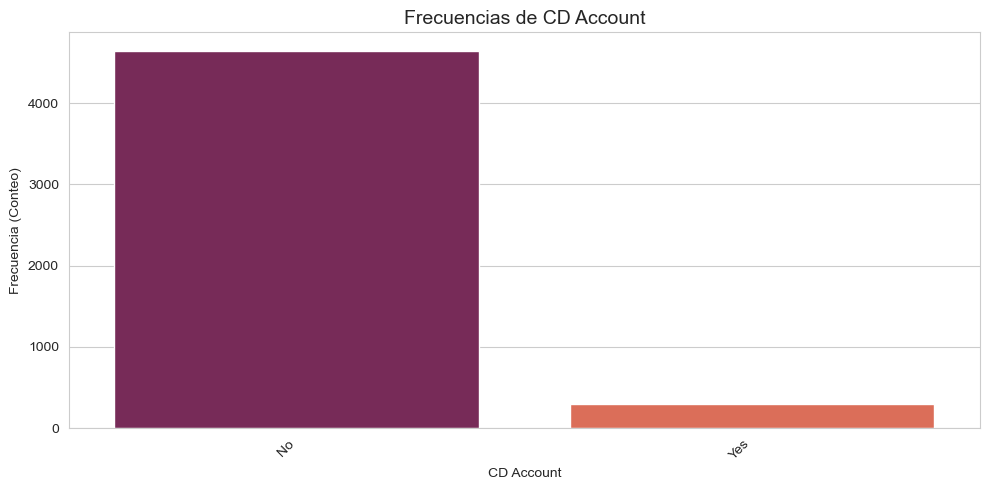

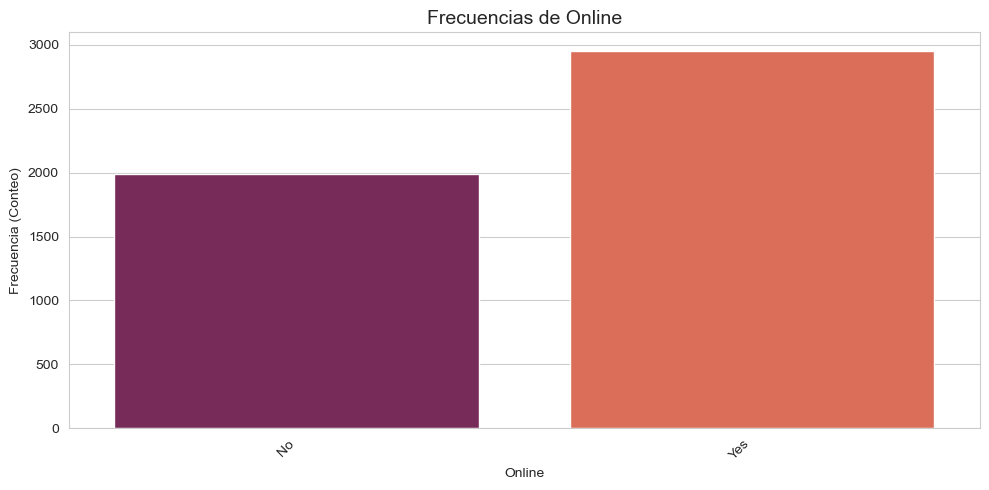

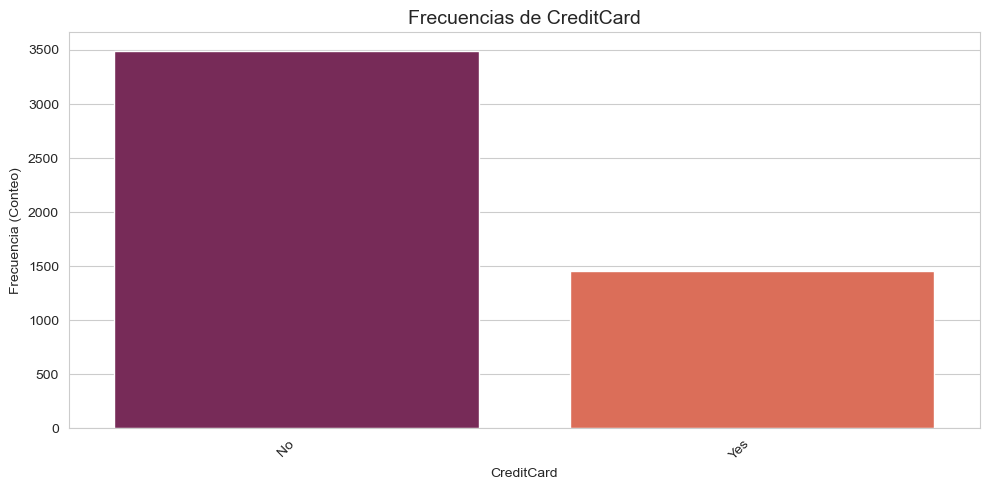

In [90]:
categorical_cols = loan_df.select_dtypes(include=['object', 'category']).columns
print(loan_df[categorical_cols].describe())

for col in categorical_cols:
    plt.figure(figsize=(10, 5))
    
    if loan_df[col].nunique() > 10:
        plot_data = loan_df[col].value_counts().head(10)
        num_unique = loan_df[col].nunique()
        title = f'Top 10 Frecuencias de {col} (Cardinalidad Alta: {num_unique} únicos)'
    else:
        plot_data = loan_df[col].value_counts()
        title = f'Frecuencias de {col}'

    sns.barplot(x=plot_data.index, y=plot_data.values, hue=plot_data.index, palette="rocket", legend=False)
    
    plt.title(title, fontsize=14)
    plt.xlabel(col)
    plt.ylabel('Frecuencia (Conteo)')
    
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

# Análisis exploratorio de datos (bivariado)

9. Obtén la matriz de gráficos de dispersión (*scatter matrix*) de todas las variables numéricas.
* Observa las relaciones entre las variables, selecciona un par representativo y describe los patrones o tendencias que sean evidentes.
* Para cuantificar la fuerza y dirección de las relaciones observadas, genera un mapa de calor con los valores de correlación de *Pearson*. ¿El valor numérico obtenido del par seleccionado se corresponde con lo esperado?

Generando Matriz de Gráficos de Dispersión (Pair Plot)...


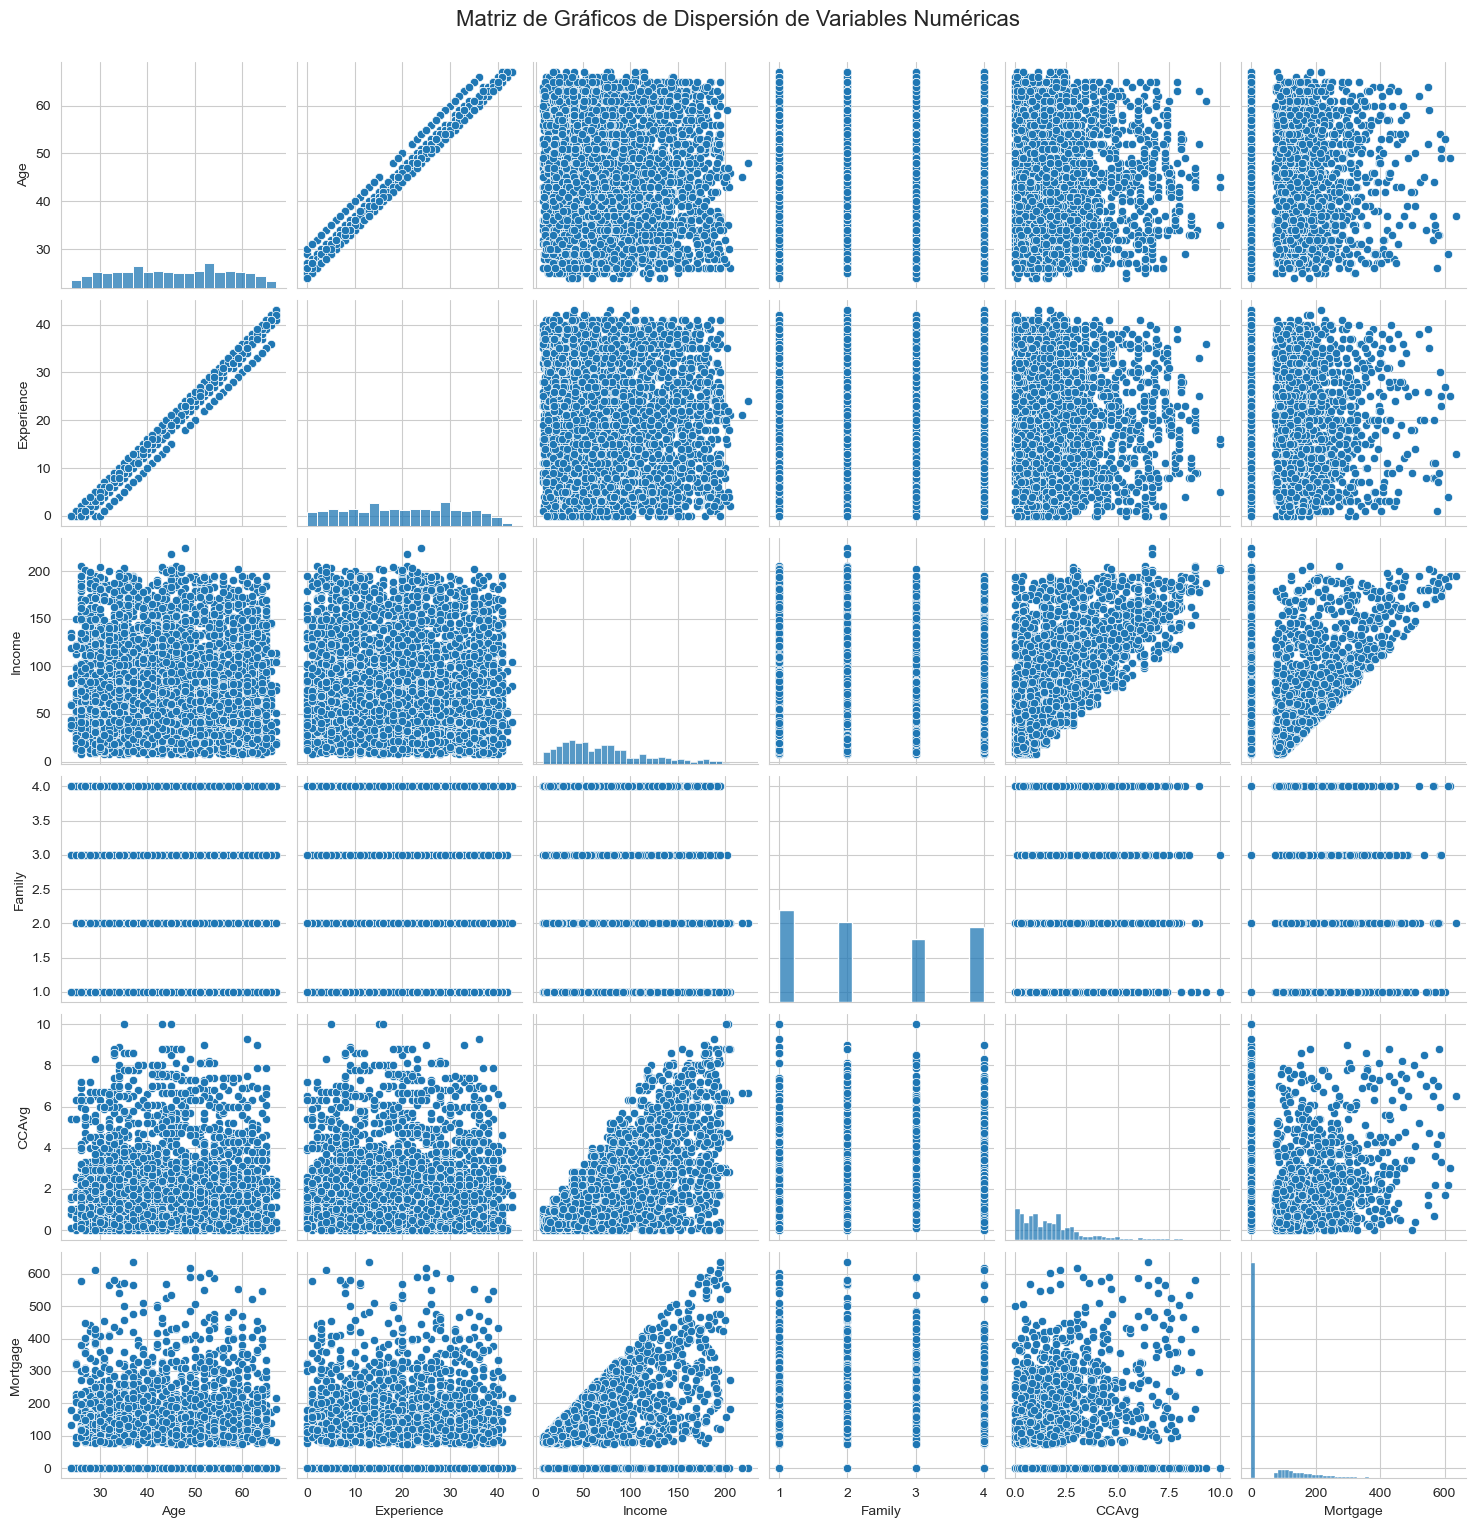


Generando Mapa de Calor de Correlación de Pearson


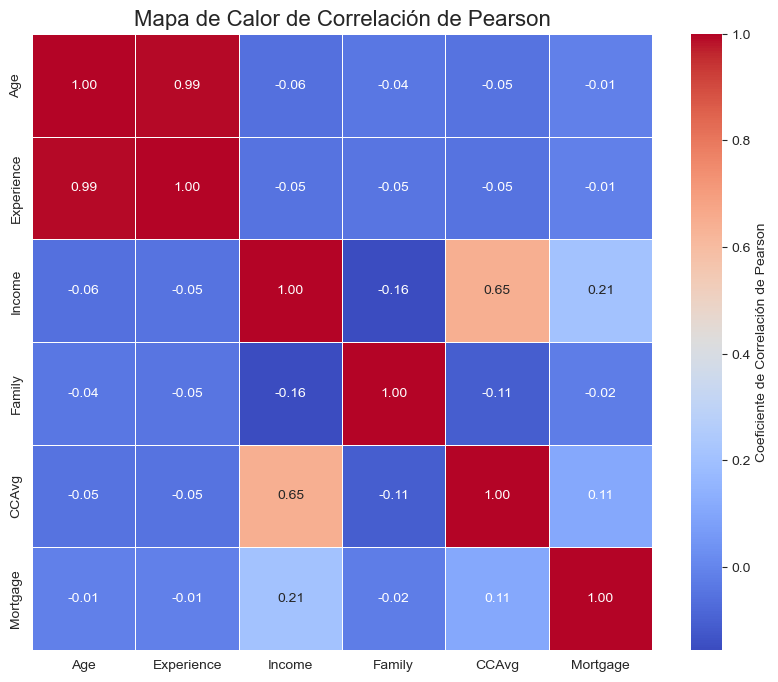

In [91]:
# Variables numéricas
variables_numericas = loan_df.select_dtypes(include=np.number).columns

print("Generando Matriz de Gráficos de Dispersión (Pair Plot)...")

# Crear el pairplot solo para las variables numéricas
sns.pairplot(loan_df[variables_numericas])
plt.suptitle('Matriz de Gráficos de Dispersión de Variables Numéricas', y=1.02, fontsize=16)
plt.show()

# --- Generación de Mapa de Calor de Correlación de Pearson ---
print("\nGenerando Mapa de Calor de Correlación de Pearson")

# 2. Calcular la matriz de correlación de Pearson
matriz_correlacion = loan_df[variables_numericas].corr(method='pearson')

plt.figure(figsize=(10, 8))
# Generar el mapa de calor con los valores de correlación
sns.heatmap(matriz_correlacion, 
            annot=True,
            cmap='coolwarm',
            fmt=".2f",
            linewidths=.5,
            cbar_kws={'label': 'Coeficiente de Correlación de Pearson'})

plt.title('Mapa de Calor de Correlación de Pearson', fontsize=16)
plt.show()

# Observa las relaciones entre las variables, selecciona un par representativo y describe los patrones o tendencias 
# que sean evidentes.

# Seleccióne las variables Age y Experience se observa una tendencia de entre más edad mayor es el grado de experienia tienen una
# correlación negativa fuerte, su relación es clara y su patron es similar.
# Seleccióne también las variables de Income y CCAvg que también muestran una tendencia entre mas Income mas es el CCAvg.
# Hay una correlación positiva fuerte.

# Para cuantificar la fuerza y dirección de las relaciones observadas, genera un mapa de calor con los valores de correlación 
# de Pearson. ¿El valor numérico obtenido del par seleccionado se corresponde con lo esperado?
# El valor numérico obtenido si corresponde a lo esperado, tal como se muestra en el mapa de calor.
# Como Incomve y CCAvg 0.65 es el unico color que se relaciona en las dos variables.



10. Realiza un análisis de todas las variables del dataset con respecto a la variable de salida `Personal Loan`.
* Variables numéricas: Genera box plots para comparar la distribución de cada variable según los valores de `Personal Loan`.
* Variables categóricas (sin considerar `ZIP Code`): Genera gráficos de barras apiladas que muestren la distribución relativa de `Personal Loan` dentro de cada categoría de la variable.
* Para cada grupo de variables (numéricas y categóricas), comenta al menos un hallazgo o patrón relevante observado en los gráficos generados.


Generando Box Plots Comparativos para Variables Numéricas


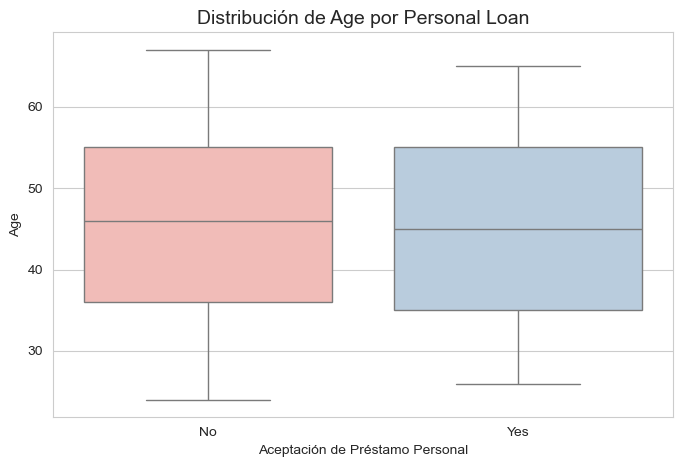

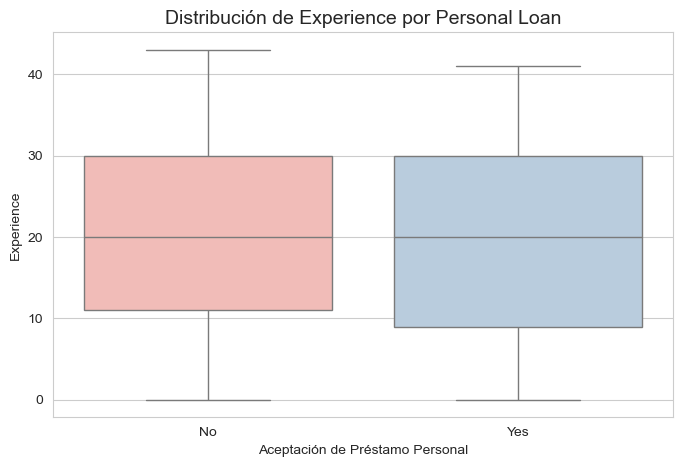

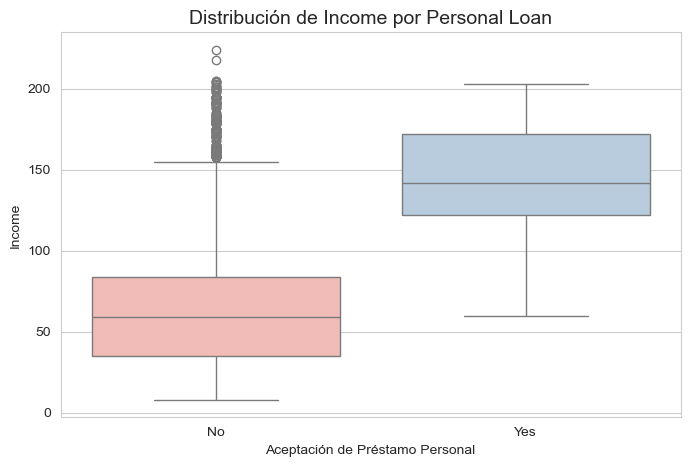

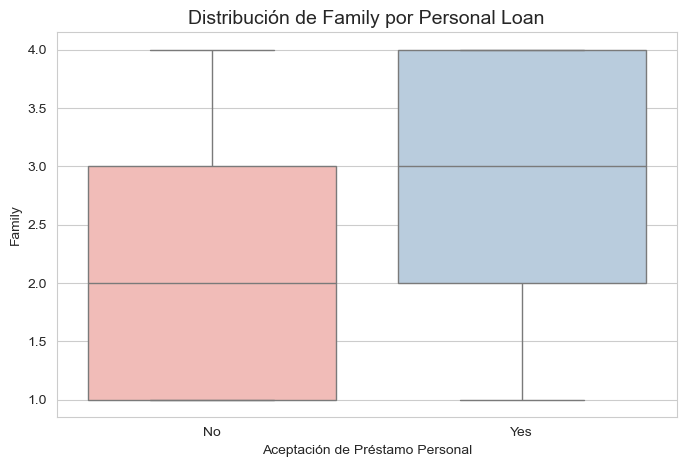

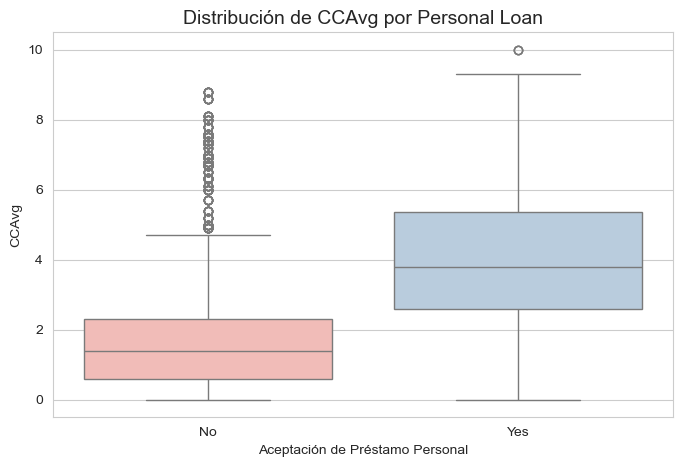

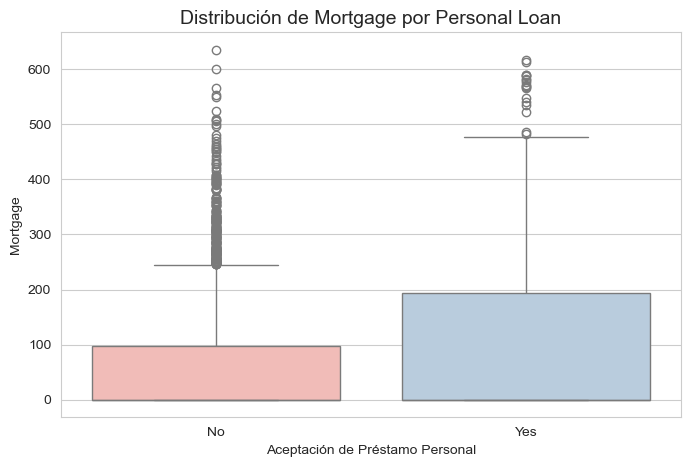

In [92]:
variables_numericas = loan_df.select_dtypes(include=np.number).columns
sns.set_style("whitegrid")
print("Generando Box Plots Comparativos para Variables Numéricas")
for col in variables_numericas:
    plt.figure(figsize=(8, 5))

    sns.boxplot(x='Personal Loan', y=col, data=loan_df, 
                hue='Personal Loan', palette="Pastel1", legend=False)
    
    plt.title(f'Distribución de {col} por Personal Loan', fontsize=14)
    plt.xlabel('Aceptación de Préstamo Personal')
    plt.ylabel(col)
    plt.show()


    # Para las personas que aceptaron el prestamo personal es mas alta que la mediana para los que no aceptaron el prestamo personal.
    # El Income indica que a mayor ingreso el banco o institución bancaria ofrece mas prestamos personales.


Generando Gráficos de Barras Apiladas para Variables Categóricas


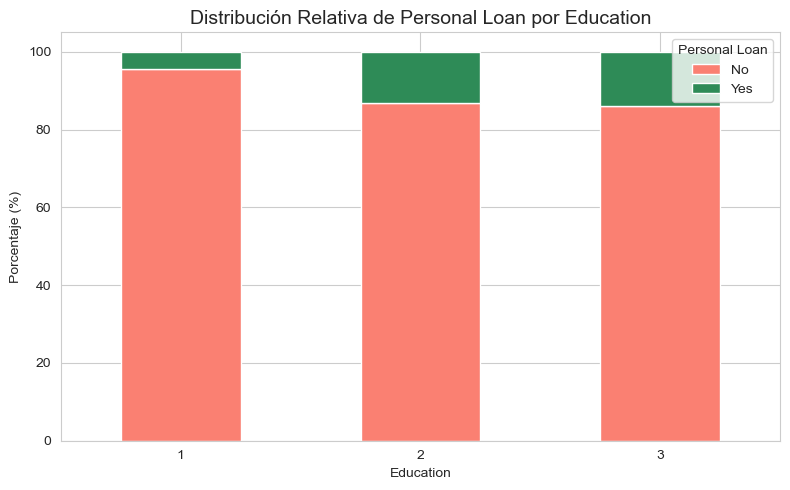

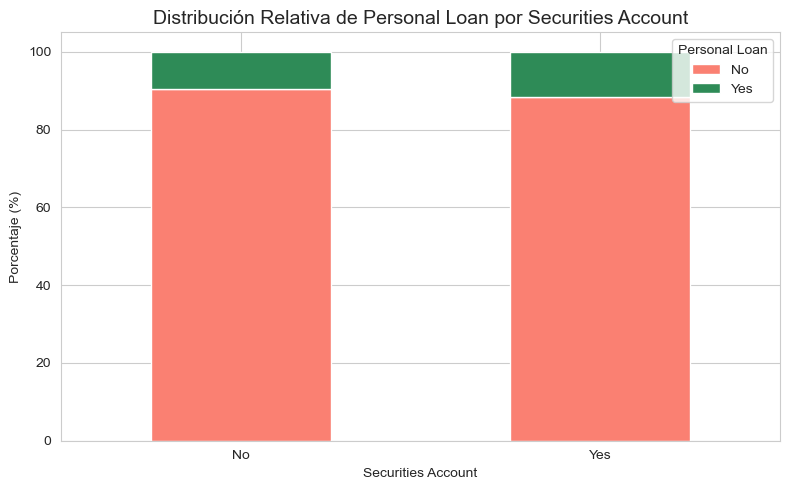

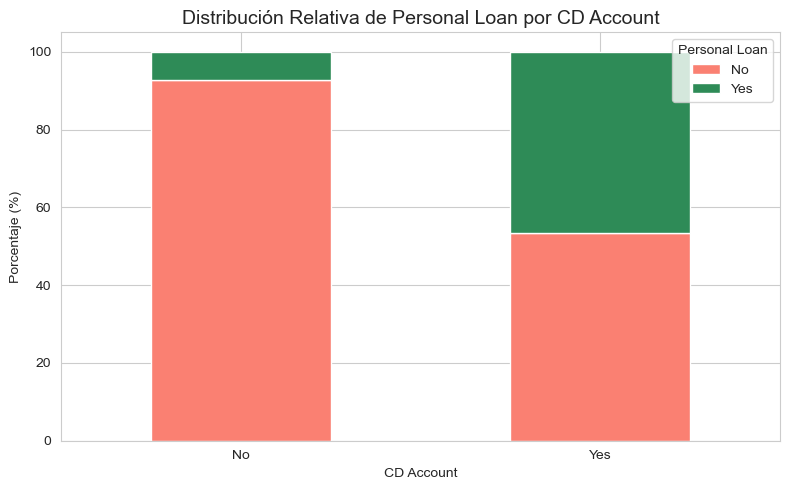

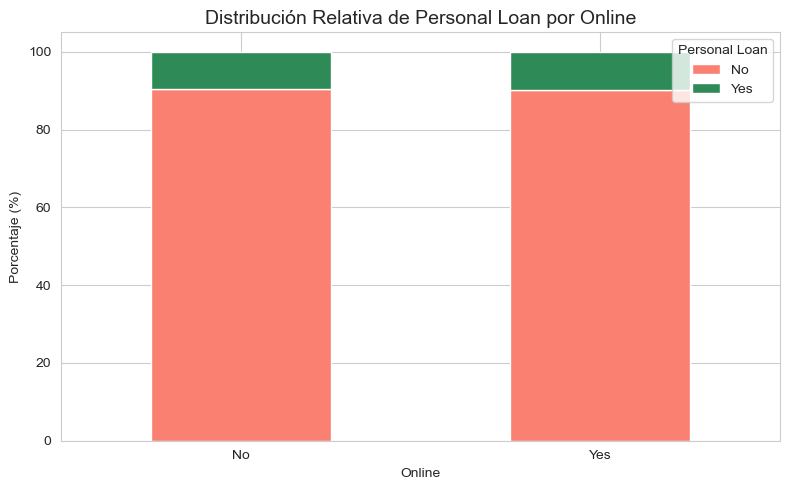

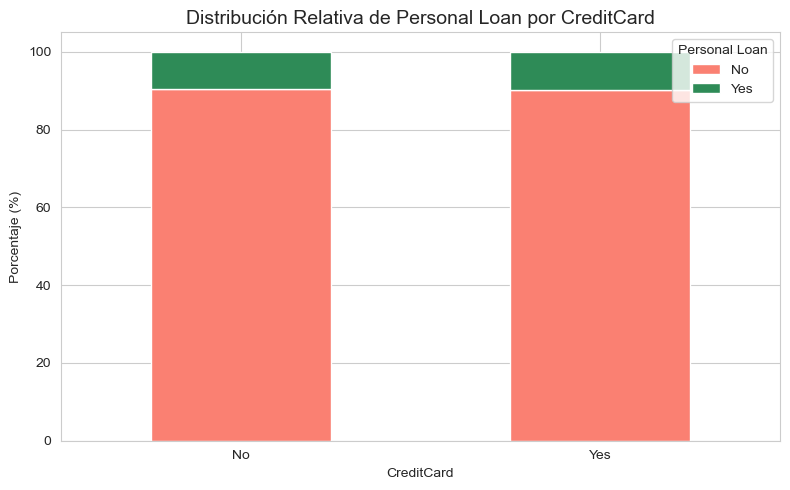

In [93]:
all_categorical_cols = loan_df.select_dtypes(include=['object', 'category']).columns
variables_categoricas = [col for col in all_categorical_cols if col != 'ZIP Code' and col != 'Personal Loan']

print("\nGenerando Gráficos de Barras Apiladas para Variables Categóricas")

# Generar gráfico de barras apiladas para cada variable categórica
for col in variables_categoricas:
    plt.figure(figsize=(8, 5))
    crosstab_normalized = pd.crosstab(loan_df[col], loan_df['Personal Loan'], normalize='index') * 100
    
    crosstab_normalized.plot(kind='bar', stacked=True, color=['salmon', 'seagreen'], ax=plt.gca())
    
    plt.title(f'Distribución Relativa de Personal Loan por {col}', fontsize=14)
    plt.xlabel(col)
    plt.ylabel('Porcentaje (%)')
    plt.xticks(rotation=0)
    plt.legend(title='Personal Loan', loc='upper right')
    plt.tight_layout()
    plt.show()

    # El prestamo personal por Educación se ve claramente que entre mas grado de educación, mas son propensos a recibir el 
    # prestamo personal, esto va de la mano a que tiene mayor ingreso.